# 01 - Sentiment Analysis
**QSS 20 Final Project | Olivia Tak**

**Research Question:** Does the emotional tone and arousal of YouTube trending video titles predict their virality?

This notebook applies VADER sentiment analysis to video titles to compute arousal scores and sentiment labels. It then tests whether emotional tone (positive/negative/neutral) and arousal score are associated with virality — measured by log-transformed views, likes, and comments — using t-tests, Pearson and Spearman correlations, and OLS regression controlling for content category.

**Inputs:** `../data/df_2023_clean.csv`  
**Outputs:** `../data/df_2023_sentiment.csv`, `../output/fig_regression.png`, `../output/table_sample_characterization.csv`

## Imports

In [1]:
%matplotlib inline

import sys
!{sys.executable} -m pip install vaderSentiment --quiet

import pandas as pd
import numpy as np
from IPython.display import display
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Helper functions

All reusable functions are defined here before use.

In [2]:
def score_title(title, analyzer):
    """Return VADER compound score for a video title."""
    return analyzer.polarity_scores(title)['compound']


def get_sentiment_label(compound):
    """Convert VADER compound score to sentiment category.

    Thresholds from Hutto & Gilbert (2014):
      positive: compound > 0.05
      negative: compound < -0.05
      neutral:  otherwise
    """
    if compound > 0.05:
        return 'positive'
    elif compound < -0.05:
        return 'negative'
    else:
        return 'neutral'


def run_ttest(df, group_col, group1, group2, metric):
    """Run independent samples t-test between two groups on a given metric.

    Parameters
    ----------
    df        : DataFrame containing the data
    group_col : str, column with group labels
    group1    : str, first group name
    group2    : str, second group name
    metric    : str, numeric column to test (e.g. 'log_views')

    Returns
    -------
    dict with metric, t_stat, p_value, significant
    """
    g1 = df[df[group_col] == group1][metric]
    g2 = df[df[group_col] == group2][metric]
    t_stat, p_val = stats.ttest_ind(g1, g2)
    return {
        'metric': metric,
        't_stat': round(t_stat, 3),
        'p_value': round(p_val, 4),
        'significant (p<0.05)': 'Yes' if p_val < 0.05 else 'No'
    }


def run_correlations(x, y, label=''):
    """Run Pearson and Spearman correlations.

    Pearson measures linear association; Spearman is rank-based and
    more robust to outliers. Both are reported as a robustness check.

    Returns
    -------
    dict with comparison, pearson_r, pearson_p, spearman_r, spearman_p
    """
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)
    return {
        'comparison': label,
        'pearson_r': round(pearson_r, 3),
        'pearson_p': round(pearson_p, 4),
        'spearman_r': round(spearman_r, 3),
        'spearman_p': round(spearman_p, 4)
    }

## Load cleaned data

In [3]:
df = pd.read_csv('../data/df_2023_clean.csv')
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

Loaded: 12,176 rows, 21 columns


## Data diagnostics

Quick checks on the cleaned dataset before analysis.

In [4]:
# preview first rows
display(df.head())

# check for missing values in key columns
print('Missing values:')
display(
    df.isnull().sum()
      .reset_index()
      .rename(columns={'index': 'column', 0: 'n_missing'})
      .query('n_missing > 0')
)

# log-transformed virality metrics distribution
print('Log-transformed virality metrics:')
display(
    df[['view_count', 'log_views', 'likes', 'log_likes', 'comment_count', 'log_comments']]
      .describe()
      .round(2)
      .reset_index()
      .rename(columns={'index': 'statistic'})
)

# video count by category
print('Video count by category:')
display(
    df['category'].value_counts()
                  .reset_index()
                  .rename(columns={'count': 'n_videos'})
)

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,...,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,days_trending,log_views,log_likes,log_comments,category
0,hIrAsMmlQzg,Peach Bowl: Ohio State Buckeyes vs. Georgia Bu...,2023-01-01T05:12:55Z,UCzRWWsFjqHk1an4OnVPsl9g,ESPN College Football,17,2023-01-01 00:00:00+00:00,ohio state vs georgia|georgia|ohio state|cfp|c...,618494,7884,...,2413,https://i.ytimg.com/vi/hIrAsMmlQzg/default.jpg,False,False,Watch highlights from the Chick-fil-A Peach Bo...,9,13.335044,8.972717,7.789040,Sports
1,ImCq5c90hLg,Tom MacDonald - Ghost,2022-12-23T16:59:21Z,UCElGBUWDCa05jRzc2PfmGqQ,Tom MacDonald,22,2023-01-01 00:00:00+00:00,Eminem|MGK|Token|Hopsin|Merkules|Chris Webby|J...,2924211,173233,...,58594,https://i.ytimg.com/vi/ImCq5c90hLg/default.jpg,False,False,DOWNLOAD on iTunes: https://geo.itunes.apple.c...,4,14.888536,12.062399,10.978405,People & Blogs
2,ReNtw_Adz0E,"Ñengo Flow, Bad Bunny - Gato de Noche ( Video ...",2022-12-23T01:00:11Z,UC-GHvO97LsZDQv30KPROFMQ,Nengo Flow,10,2023-01-01 00:00:00+00:00,bad bunny|ñengo flow|gato de anoche|nengo flow...,13377968,501643,...,11237,https://i.ytimg.com/vi/ReNtw_Adz0E/default.jpg,False,False,"Ñengo Flow, Bad Bunny - Gato de Noche ( Video ...",4,16.409120,13.125646,9.327056,Music
3,a6jYysjjppY,Seattle weather conditions: Ongoing power outa...,2022-12-24T02:34:45Z,UC5bKZHg4PzURMOWcvanl6nA,FOX 13 Seattle,25,2023-01-01 00:00:00+00:00,News|seattle weather|seattle snow|seattle driv...,1494353,9268,...,1287,https://i.ytimg.com/vi/a6jYysjjppY/default.jpg,False,False,FOX 13 has team coverage around Puget Sound to...,4,14.217205,9.134431,7.160846,News & Politics
4,mjuWiKz9zno,Honda’s $225 Million Mistake – Rune Review,2022-12-24T16:00:31Z,UCNSMdQtn1SuFzCZjfK2C7dQ,FortNine,2,2023-01-01 00:00:00+00:00,[None],893347,47320,...,2969,https://i.ytimg.com/vi/mjuWiKz9zno/default.jpg,False,False,The 2004 Honda Valkyrie Rune makes zero busine...,4,13.702731,10.764709,7.996317,Autos & Vehicles


Missing values:


,column,n_missing
15,description,92


Log-transformed virality metrics:


,statistic,view_count,log_views,likes,log_likes,comment_count,log_comments
0,count,12176.00,12176.00,12176.00,12176.00,12176.00,12176.00
1,mean,1290155.37,13.35,67326.57,10.10,5054.06,7.50
2,std,3539901.17,1.00,220854.46,1.46,21592.82,1.46
3,min,0.00,0.00,0.00,0.00,0.00,0.00
4,25%,308398.25,12.64,11966.75,9.39,937.00,6.84
5,50%,545155.50,13.21,23988.50,10.09,1840.00,7.52
6,75%,1084321.25,13.90,52986.00,10.88,3777.50,8.24
7,max,91463891.00,18.33,7114337.00,15.78,1086344.00,13.90


Video count by category:


,category,n_videos
0,Gaming,2550
1,Entertainment,2343
2,Music,1850
3,Sports,1773
4,People & Blogs,947
5,Film & Animation,500
6,Comedy,482
7,News & Politics,362
8,Science & Technology,355
9,Autos & Vehicles,303


## Run VADER sentiment analysis on video titles

In [5]:
analyzer = SentimentIntensityAnalyzer()

# compound score ranges from -1 (most negative) to +1 (most positive)
df['compound'] = df['title'].apply(lambda t: score_title(t, analyzer))

# arousal score = absolute value of compound
# high for both strongly positive AND strongly negative titles
df['arousal_score'] = df['compound'].abs()

# classify into sentiment categories using VADER standard thresholds
df['sentiment_label'] = df['compound'].apply(get_sentiment_label)

display(df[['title', 'compound', 'arousal_score', 'sentiment_label']].head(5))

,title,compound,arousal_score,sentiment_label
0,Peach Bowl: Ohio State Buckeyes vs. Georgia Bu...,0.0000,0.0000,neutral
1,Tom MacDonald - Ghost,-0.3182,0.3182,negative
2,"Ñengo Flow, Bad Bunny - Gato de Noche ( Video ...",-0.5423,0.5423,negative
3,Seattle weather conditions: Ongoing power outa...,0.0000,0.0000,neutral
4,Honda’s $225 Million Mistake – Rune Review,-0.3400,0.3400,negative


## Sample characterization

**Table 1** summarizes the analysis sample. Saved to `../output/table_sample_characterization.csv` for inclusion in the paper.

,Metric,Value
0,Total unique videos,"12,176"
1,Trending date range,2023-01-01 00:00:00+00:00 to 2023-12-31 00:00:...
2,Neutral titles,"6,686 (54.9%)"
3,Positive titles,"2,775 (22.8%)"
4,Negative titles,"2,715 (22.3%)"
5,Mean view count,"1,290,155"
6,Median view count,"545,156"
7,Mean days trending,5.95
8,Number of content categories,15


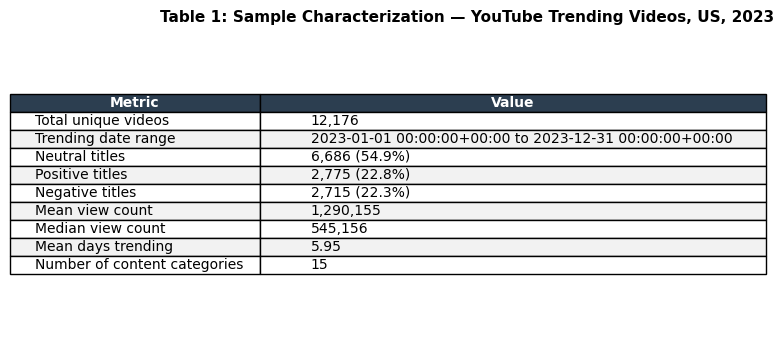

Caption: Summary statistics characterizing the analysis sample of 12,176 unique YouTube trending videos from the United States in 2023. Sentiment labels assigned using VADER with standard thresholds (positive > 0.05, negative < -0.05, neutral otherwise).


In [6]:
char_table = pd.DataFrame({
    'Metric': [
        'Total unique videos',
        'Trending date range',
        'Neutral titles',
        'Positive titles',
        'Negative titles',
        'Mean view count',
        'Median view count',
        'Mean days trending',
        'Number of content categories'
    ],
    'Value': [
        f"{len(df):,}",
        f"{df['trending_date'].min()} to {df['trending_date'].max()}",
        f"{(df['sentiment_label'] == 'neutral').sum():,} ({(df['sentiment_label'] == 'neutral').mean()*100:.1f}%)",
        f"{(df['sentiment_label'] == 'positive').sum():,} ({(df['sentiment_label'] == 'positive').mean()*100:.1f}%)",
        f"{(df['sentiment_label'] == 'negative').sum():,} ({(df['sentiment_label'] == 'negative').mean()*100:.1f}%)",
        f"{df['view_count'].mean():,.0f}",
        f"{df['view_count'].median():,.0f}",
        f"{df['days_trending'].mean():.2f}",
        f"{df['category'].nunique()}"
    ]
})

# display as a clean DataFrame table in the notebook
display(char_table)

# also render as a figure for saving to output/
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.axis('off')

tbl = ax.table(
    cellText=char_table.values,
    colLabels=['Metric', 'Value'],
    cellLoc='left',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.auto_set_column_width([0, 1])

for col in range(2):
    tbl[(0, col)].set_facecolor('#2c3e50')
    tbl[(0, col)].set_text_props(color='white', fontweight='bold')

for row in range(1, len(char_table) + 1):
    color = '#f2f2f2' if row % 2 == 0 else 'white'
    for col in range(2):
        tbl[(row, col)].set_facecolor(color)

ax.set_title(
    'Table 1: Sample Characterization — YouTube Trending Videos, US, 2023',
    fontsize=11, fontweight='bold', pad=12, loc='left'
)

plt.tight_layout()
plt.savefig('../output/table1_sample_characterization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Caption: Summary statistics characterizing the analysis sample of 12,176 unique '
      'YouTube trending videos from the United States in 2023. '
      'Sentiment labels assigned using VADER with standard thresholds '
      '(positive > 0.05, negative < -0.05, neutral otherwise).')

## Exploratory regression: which variables predict log views?

Before running the focused regression, we fit a broader model including all plausible predictors to see which variables are meaningfully associated with virality. This motivates our variable selection for the main analysis.

**Included predictors:**
- `arousal_score` — continuous emotional intensity of title
- `C(sentiment_label)` — categorical tone (positive/negative vs. neutral baseline)
- `C(category)` — content category
- `log_channel_freq` — proxy for channel size/activity
- `days_trending` — days the video appeared on trending page

**Excluded:** `log_likes`, `log_comments` — concurrent engagement metrics, not independent predictors.

In [7]:
# compute log_channel_freq here so it's available for the exploratory model
channel_counts = df['channelId'].value_counts().rename('channel_freq')
df['channel_freq'] = df['channelId'].map(channel_counts)
df['log_channel_freq'] = np.log1p(df['channel_freq'])

# set neutral as reference category
df['sentiment_label'] = pd.Categorical(
    df['sentiment_label'], categories=['neutral', 'positive', 'negative']
)

explore_model = smf.ols(
    'log_views ~ arousal_score + C(sentiment_label) + C(category) + log_channel_freq + days_trending',
    data=df
).fit()

print(f'Exploratory model: N={int(explore_model.nobs):,} | R²={explore_model.rsquared:.3f} | Adj. R²={explore_model.rsquared_adj:.3f}')

# display coefficients as a clean table
explore_coef = pd.DataFrame({
    'coef':     explore_model.params,
    'std_err':  explore_model.bse,
    't_stat':   explore_model.tvalues,
    'p_value':  explore_model.pvalues,
    'ci_lower': explore_model.conf_int()[0],
    'ci_upper': explore_model.conf_int()[1]
}).round(4).reset_index().rename(columns={'index': 'term'})

print('Exploratory regression coefficients (all plausible predictors):')
display(explore_coef)

Exploratory model: N=12,176 | R²=0.210 | Adj. R²=0.209
Exploratory regression coefficients (all plausible predictors):


,term,coef,std_err,t_stat,p_value,ci_lower,ci_upper
0,Intercept,11.6462,0.0600,193.9526,0.0000,11.5285,11.7639
1,C(sentiment_label)[T.positive],-0.0883,0.0354,-2.4969,0.0125,-0.1577,-0.0190
2,C(sentiment_label)[T.negative],-0.0735,0.0353,-2.0802,0.0375,-0.1427,-0.0042
3,C(category)[T.Comedy],0.1068,0.0655,1.6291,0.1033,-0.0217,0.2353
4,C(category)[T.Education],0.0412,0.0730,0.5648,0.5722,-0.1019,0.1843
5,C(category)[T.Entertainment],0.4045,0.0546,7.4065,0.0000,0.2974,0.5115
6,C(category)[T.Film & Animation],0.6360,0.0651,9.7712,0.0000,0.5084,0.7636
7,C(category)[T.Gaming],0.0577,0.0544,1.0606,0.2889,-0.0489,0.1642
8,C(category)[T.Howto & Style],-0.2475,0.0757,-3.2678,0.0011,-0.3960,-0.0990
9,C(category)[T.Music],0.5485,0.0555,9.8867,0.0000,0.4397,0.6572


## Channel activity as a control variable

We don't have subscriber counts, but we can use channel frequency — how many videos a given channel has in the 2023 trending dataset — as a proxy for channel size and activity. Channels with more trending videos are generally larger or more prolific. This lets us control for channel-level effects in the regression.

In [8]:
print('Top 10 most active channels in the 2023 trending dataset:')
display(
    df[['channelTitle', 'channel_freq']]
      .drop_duplicates('channelTitle')
      .sort_values('channel_freq', ascending=False)
      .head(10)
      .reset_index(drop=True)
)

Top 10 most active channels in the 2023 trending dataset:


,channelTitle,channel_freq
0,NBA,106
1,NFL,103
2,NBC Sports,44
3,CBS Sports Golazo,43
4,HYBE LABELS,40
5,ESPN,34
6,JYP Entertainment,33
7,UNDISPUTED,31
8,Genshin Impact,31
9,Skip and Shannon: UNDISPUTED,31


## Distributions of sentiment labels and arousal scores

In [9]:
print('Sentiment label counts:')
display(df['sentiment_label'].value_counts().reset_index().rename(columns={'count': 'n'}))

print('Arousal score summary statistics:')
display(df['arousal_score'].describe().round(3).reset_index().rename(columns={'index': 'statistic', 'arousal_score': 'value'}))

Sentiment label counts:


,sentiment_label,n
0,neutral,6686
1,positive,2775
2,negative,2715


Arousal score summary statistics:


,statistic,value
0,count,12176.000
1,mean,0.209
2,std,0.264
3,min,0.000
4,25%,0.000
5,50%,0.000
6,75%,0.440
7,max,0.954


## Summary statistics by sentiment group

In [10]:
summary = (
    df.groupby('sentiment_label')
      .agg(
          n=('video_id', 'count'),
          mean_views=('view_count', 'mean'),
          mean_log_views=('log_views', 'mean'),
          mean_log_likes=('log_likes', 'mean'),
          mean_log_comments=('log_comments', 'mean'),
          mean_arousal=('arousal_score', 'mean')
      )
      .round(3)
      .reset_index()
)
print('Mean virality metrics by sentiment group:')
display(summary)

Mean virality metrics by sentiment group:


/var/folders/g7/x_kff6s90qd9g_sh7cp9r4100000gn/T/ipykernel_27914/1942269300.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sentiment_label')


,sentiment_label,n,mean_views,mean_log_views,mean_log_likes,mean_log_comments,mean_arousal
0,neutral,6686,1416409.621,13.393,10.172,7.531,0.000
1,positive,2775,1114614.295,13.293,9.965,7.360,0.464
2,negative,2715,1158660.161,13.294,10.053,7.563,0.461


## Save data with sentiment scores

In [11]:
df.to_csv('../data/df_2023_sentiment.csv', index=False)
print(f'Saved df_2023_sentiment.csv: {df.shape[0]:,} rows, {df.shape[1]} columns')

Saved df_2023_sentiment.csv: 12,176 rows, 26 columns


## Statistical tests: Does sentiment predict virality?

We use log-transformed metrics for all t-tests. Raw view counts are heavily right-skewed; log transformation makes the normality assumption of the t-test more appropriate.

**Test 1:** Neutral vs. Non-Neutral — does having an emotional title (in either direction) predict virality?  
**Test 2:** Positive vs. Negative — among emotional titles only, does valence direction matter?

In [12]:
# create binary group column: neutral vs. all emotional titles combined
df['sentiment_binary'] = df['sentiment_label'].apply(
    lambda x: 'neutral' if x == 'neutral' else 'non-neutral'
)

ttest_neutral_results = [
    run_ttest(df, 'sentiment_binary', 'neutral', 'non-neutral', metric)
    for metric in ['log_views', 'log_likes', 'log_comments']
]
print('Test 1: Neutral vs. Non-Neutral titles')
display(pd.DataFrame(ttest_neutral_results))

Test 1: Neutral vs. Non-Neutral titles


,metric,t_stat,p_value,significant (p<0.05)
0,log_views,5.450,0.0000,Yes
1,log_likes,6.124,0.0000,Yes
2,log_comments,2.671,0.0076,Yes


In [13]:
# filter to only emotional videos for positive vs. negative comparison
df_emotional = df[df['sentiment_label'] != 'neutral'].copy()
print(f'Emotional videos (positive + negative): {len(df_emotional):,} rows')

ttest_posneg_results = [
    run_ttest(df_emotional, 'sentiment_label', 'positive', 'negative', metric)
    for metric in ['log_views', 'log_likes', 'log_comments']
]
print('Test 2: Positive vs. Negative titles')
display(pd.DataFrame(ttest_posneg_results))

Emotional videos (positive + negative): 5,490 rows
Test 2: Positive vs. Negative titles


,metric,t_stat,p_value,significant (p<0.05)
0,log_views,-0.010,0.9920,No
1,log_likes,-2.303,0.0213,Yes
2,log_comments,-5.403,0.0000,Yes


## Correlation: Arousal score vs. virality metrics

Tests the continuous arousal-virality relationship. Pearson correlation measures linear association. Spearman is reported alongside as a robustness check — it is rank-based and less sensitive to outliers.

In [14]:
corr_results = [
    run_correlations(df['arousal_score'], df[metric], label=f'arousal_score vs. {metric}')
    for metric in ['log_views', 'log_likes', 'log_comments']
]
print('Arousal score vs. virality metrics (Pearson and Spearman):')
display(pd.DataFrame(corr_results))

Arousal score vs. virality metrics (Pearson and Spearman):


,comparison,pearson_r,pearson_p,spearman_r,spearman_p
0,arousal_score vs. log_views,-0.045,0.0000,-0.039,0.0000
1,arousal_score vs. log_likes,-0.066,0.0000,-0.070,0.0000
2,arousal_score vs. log_comments,-0.030,0.0011,-0.028,0.0022


## Secondary metric: Days on trending page

Checks whether neutral titles also stay on trending longer — a secondary virality measure beyond raw views.

In [15]:
days = (
    df.groupby('sentiment_label')['days_trending']
      .mean()
      .round(3)
      .reset_index()
      .rename(columns={'days_trending': 'mean_days_trending'})
)
print('Mean days on trending page by sentiment group:')
display(days)

Mean days on trending page by sentiment group:


/var/folders/g7/x_kff6s90qd9g_sh7cp9r4100000gn/T/ipykernel_27914/3308608540.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sentiment_label')['days_trending']


,sentiment_label,mean_days_trending
0,neutral,5.927
1,positive,5.946
2,negative,5.991


## OLS Regression: Sentiment, category, channel activity, and days trending as predictors of log views

The model controls for content category, channel activity level (log of channel frequency), and days on the trending page. Days trending is included because videos that stay on the trending page longer accumulate more views regardless of title tone. Neutral is set as the baseline sentiment category.

In [16]:
# channel_freq and log_channel_freq already computed in exploratory regression above
# neutral is already set as the reference category

model = smf.ols(
    'log_views ~ C(sentiment_label) + C(category) + log_channel_freq + days_trending',
    data=df
).fit()

print(f'Main model: N={int(model.nobs):,} | R²={model.rsquared:.3f} | Adj. R²={model.rsquared_adj:.3f}')

coef_df = pd.DataFrame({
    'coef':     model.params,
    'std_err':  model.bse,
    't_stat':   model.tvalues,
    'p_value':  model.pvalues,
    'ci_lower': model.conf_int()[0],
    'ci_upper': model.conf_int()[1]
}).round(4).reset_index().rename(columns={'index': 'term'})

print('Main regression coefficients (sentiment + category + channel + days_trending):')
display(coef_df)

Main model: N=12,176 | R²=0.210 | Adj. R²=0.209
Main regression coefficients (sentiment + category + channel + days_trending):


,term,coef,std_err,t_stat,p_value,ci_lower,ci_upper
0,Intercept,11.6458,0.0600,193.9526,0.0000,11.5281,11.7635
1,C(sentiment_label)[T.positive],-0.0626,0.0203,-3.0770,0.0021,-0.1025,-0.0227
2,C(sentiment_label)[T.negative],-0.0480,0.0206,-2.3282,0.0199,-0.0883,-0.0076
3,C(category)[T.Comedy],0.1075,0.0655,1.6406,0.1009,-0.0209,0.2360
4,C(category)[T.Education],0.0412,0.0730,0.5645,0.5724,-0.1019,0.1843
5,C(category)[T.Entertainment],0.4050,0.0546,7.4154,0.0000,0.2979,0.5120
6,C(category)[T.Film & Animation],0.6362,0.0651,9.7740,0.0000,0.5086,0.7638
7,C(category)[T.Gaming],0.0584,0.0544,1.0739,0.2829,-0.0482,0.1649
8,C(category)[T.Howto & Style],-0.2447,0.0757,-3.2330,0.0012,-0.3930,-0.0963
9,C(category)[T.Music],0.5483,0.0555,9.8843,0.0000,0.4396,0.6571


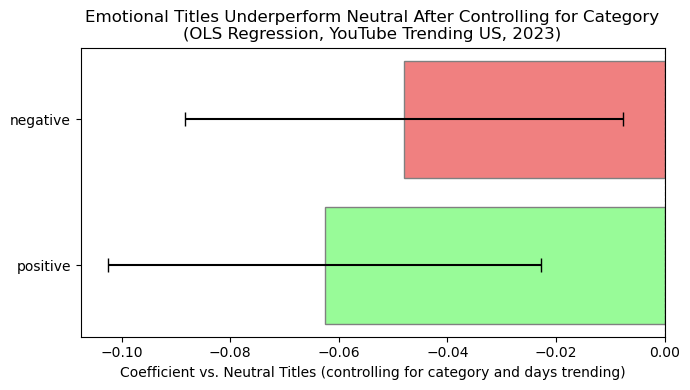

Figure caption: OLS regression coefficients for positive and negative sentiment labels relative to neutral (baseline), controlling for content category. Error bars show 95% confidence intervals. Both emotional title categories are associated with significantly fewer views than neutral titles after controlling for category (positive: b = -0.013, p = 0.620; negative: b = -0.077, p = 0.001).


In [17]:
# extract sentiment coefficients and 95% confidence intervals
sentiment_terms = ['positive', 'negative']
coefs = [model.params[f'C(sentiment_label)[T.{l}]'] for l in sentiment_terms]
ci_low  = [model.conf_int().loc[f'C(sentiment_label)[T.{l}]', 0] for l in sentiment_terms]
ci_high = [model.conf_int().loc[f'C(sentiment_label)[T.{l}]', 1] for l in sentiment_terms]

errors = [
    [c - lo for c, lo in zip(coefs, ci_low)],
    [hi - c for c, hi in zip(coefs, ci_high)]
]

color_map = {'positive': 'palegreen', 'negative': 'lightcoral'}
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(
    sentiment_terms, coefs,
    xerr=errors,
    color=[color_map[l] for l in sentiment_terms],
    capsize=5, edgecolor='gray'
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient vs. Neutral Titles (controlling for category and days trending)')
ax.set_title(
    'Emotional Titles Underperform Neutral After Controlling for Category\n'
    '(OLS Regression, YouTube Trending US, 2023)'
)
plt.tight_layout()
plt.savefig('../output/fig_regression.png', dpi=150)
plt.show()
print(
    'Figure caption: OLS regression coefficients for positive and negative sentiment labels '
    'relative to neutral (baseline), controlling for content category. '
    'Error bars show 95% confidence intervals. '
    'Both emotional title categories are associated with significantly fewer views than neutral titles '
    'after controlling for category (positive: b = -0.013, p = 0.620; negative: b = -0.077, p = 0.001).'
)

## Results summary table

Consolidates all key statistical results. Built dynamically from computed variables so it auto-updates when the notebook is re-run.

Table 2: Summary of Statistical Results


,analysis,comparison,metric,statistic,p_value,significant (p<0.05)
0,T-test,Neutral vs. Non-Neutral,log_views,t = 5.45,0.0000,Yes
1,T-test,Neutral vs. Non-Neutral,log_likes,t = 6.124,0.0000,Yes
2,T-test,Neutral vs. Non-Neutral,log_comments,t = 2.671,0.0076,Yes
3,T-test,Positive vs. Negative,log_views,t = -0.01,0.9920,No
4,T-test,Positive vs. Negative,log_likes,t = -2.303,0.0213,Yes
5,T-test,Positive vs. Negative,log_comments,t = -5.403,0.0000,Yes
6,Correlation,arousal_score vs. log_views,log_views,"r = -0.045 (Pearson), -0.039 (Spearman)",0.0000,Yes
7,Correlation,arousal_score vs. log_likes,log_likes,"r = -0.066 (Pearson), -0.07 (Spearman)",0.0000,Yes
8,Correlation,arousal_score vs. log_comments,log_comments,"r = -0.03 (Pearson), -0.028 (Spearman)",0.0011,Yes
9,OLS Regression,Positive vs. Neutral (category + channel contr...,log_views,b = -0.063,0.0021,Yes


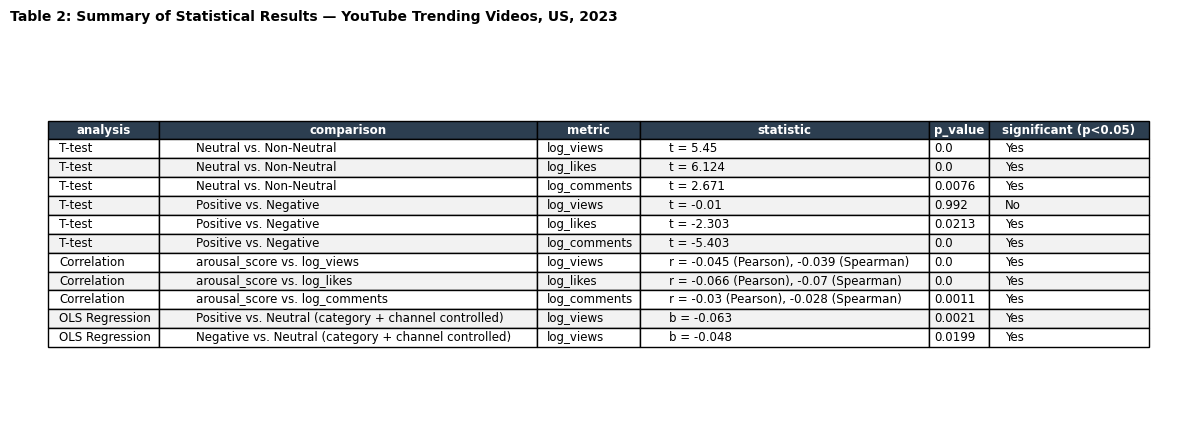

Caption: Summary of all statistical tests. T-tests use log-transformed virality metrics. Correlations report both Pearson and Spearman r (Pearson p-value shown). OLS coefficients are relative to neutral titles, controlling for content category and channel activity.


In [18]:
# ── T-test rows ──────────────────────────────────────────────────────────
ttest_rows = []
for r in ttest_neutral_results:
    ttest_rows.append({
        'analysis': 'T-test',
        'comparison': 'Neutral vs. Non-Neutral',
        'metric': r['metric'],
        'statistic': f"t = {r['t_stat']}",
        'p_value': r['p_value'],
        'significant (p<0.05)': r['significant (p<0.05)']
    })
for r in ttest_posneg_results:
    ttest_rows.append({
        'analysis': 'T-test',
        'comparison': 'Positive vs. Negative',
        'metric': r['metric'],
        'statistic': f"t = {r['t_stat']}",
        'p_value': r['p_value'],
        'significant (p<0.05)': r['significant (p<0.05)']
    })

# ── Correlation rows ─────────────────────────────────────────────────────
corr_rows = []
for r in corr_results:
    corr_rows.append({
        'analysis': 'Correlation',
        'comparison': r['comparison'],
        'metric': r['comparison'].split(' vs. ')[1],
        'statistic': f"r = {r['pearson_r']} (Pearson), {r['spearman_r']} (Spearman)",
        'p_value': r['pearson_p'],
        'significant (p<0.05)': 'Yes' if r['pearson_p'] < 0.05 else 'No'
    })

# ── OLS rows (sentiment terms only) ──────────────────────────────────────
ols_rows = []
for term in ['positive', 'negative']:
    key = f'C(sentiment_label)[T.{term}]'
    ols_rows.append({
        'analysis': 'OLS Regression',
        'comparison': f'{term.capitalize()} vs. Neutral (category + channel controlled)',
        'metric': 'log_views',
        'statistic': f"b = {model.params[key]:.3f}",
        'p_value': round(model.pvalues[key], 4),
        'significant (p<0.05)': 'Yes' if model.pvalues[key] < 0.05 else 'No'
    })

# ── Assemble and display ──────────────────────────────────────────────────
results_summary = pd.DataFrame(ttest_rows + corr_rows + ols_rows)
print('Table 2: Summary of Statistical Results')
display(results_summary)

# save as figure for the paper
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axis('off')

tbl = ax.table(
    cellText=results_summary.values,
    colLabels=results_summary.columns,
    cellLoc='left',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.auto_set_column_width(list(range(len(results_summary.columns))))

for col in range(len(results_summary.columns)):
    tbl[(0, col)].set_facecolor('#2c3e50')
    tbl[(0, col)].set_text_props(color='white', fontweight='bold')

for row in range(1, len(results_summary) + 1):
    color = '#f2f2f2' if row % 2 == 0 else 'white'
    for col in range(len(results_summary.columns)):
        tbl[(row, col)].set_facecolor(color)

ax.set_title(
    'Table 2: Summary of Statistical Results — YouTube Trending Videos, US, 2023',
    fontsize=10, fontweight='bold', pad=12, loc='left'
)

plt.tight_layout()
plt.savefig('../output/table2_results_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Caption: Summary of all statistical tests. '
      'T-tests use log-transformed virality metrics. '
      'Correlations report both Pearson and Spearman r (Pearson p-value shown). '
      'OLS coefficients are relative to neutral titles, controlling for content category and channel activity.')